#**EDA 1-- Análisis Salarial Internacional en el Sector Tech (20 países)**

Analizar la distribución salarial en el sector tecnológico y evaluar cómo varía según el nivel de experiencia, la modalidad de trabajo y la ubicación de la empresa, con el fin de identificar tendencias relevantes del mercado laboral internacional.

#Índice


1.   Exploración inicial
2.   Análisis salarial por nivel de experiencia
3.   Análisis salarial por pais.
4.   Análisis de participación de América Latina
5.   Conclusiones generales
6.   Limitaciones del dataset
7.   Futuras líneas de análisis



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Exploración inicial del dataset

En esta sección se realiza una revisión general del dataset con el objetivo de comprender su estructura, dimensiones y calidad de los datos antes de avanzar con el análisis.

In [13]:
from google.colab import files
uploaded = files.upload()


Saving ai_job_dataset (1).csv to ai_job_dataset (1) (2).csv


In [14]:
df = pd.read_csv("ai_job_dataset (1).csv")
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [15]:
df.shape

(15000, 19)

In [16]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

#Exploración inicial del dataset

En esta sección se realizó una revisión general del dataset con el objetivo de comprender su estructura, dimensiones y calidad de los datos antes de avanzar con el análisis.

El dataset contiene 15.000 registros y 19 variables. No se identificaron valores nulos en las columnas analizadas, lo que indica una base de datos completa para el estudio.

La variable salary_usd fue seleccionada como eje central del análisis por representar una métrica homogénea que permite la comparación internacional.

#Análisis de salario por nivel de experiencia.
En este bloque se analiza cómo varía la mediana salarial en función del nivel de experiencia, con el objetivo de identificar patrones de progresión dentro del mercado laboral tecnológico.

Se busca determinar si existe una relación clara entre seniority y nivel de ingresos, así como identificar posibles saltos salariales significativos entre categorías.

In [18]:
pd.options.display.float_format = '{:.2f}'.format

In [19]:
df['salary_usd'].describe()

,salary_usd
count,15000.00
mean,115348.97
std,60260.94
min,32519.00
25%,70179.75
50%,99705.00
75%,146408.50
max,399095.00


In [20]:
df.sort_values(by='salary_usd', ascending=False).head(150)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
9891,AI09892,Machine Learning Researcher,399095,USD,EX,PT,Switzerland,L,Switzerland,0,"Linux, Python, TensorFlow",Master,10,Retail,2024-07-10,2024-09-02,2277,9.70,TechCorp Inc
2309,AI02310,AI Architect,398084,USD,EX,CT,Switzerland,L,Switzerland,100,"Python, Linux, Tableau, TensorFlow",Associate,15,Automotive,2024-12-30,2025-02-20,1979,10.00,Future Systems
12499,AI12500,AI Research Scientist,394917,USD,EX,CT,Switzerland,L,Switzerland,50,"Scala, PyTorch, Spark, Docker, Git",Master,12,Real Estate,2024-06-04,2024-08-13,1310,6.60,Machine Intelligence Group
12803,AI12804,AI Specialist,390292,USD,EX,FT,Switzerland,L,Switzerland,50,"Java, SQL, PyTorch, Statistics, TensorFlow",Associate,11,Real Estate,2024-12-27,2025-01-24,1900,7.50,DataVision Ltd
317,AI00318,Data Scientist,388754,USD,EX,CT,Switzerland,L,United States,0,"Docker, Python, Mathematics",Master,16,Transportation,2024-06-20,2024-08-11,829,8.60,DeepTech Ventures
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,AI02398,Data Analyst,308706,USD,EX,FT,Norway,L,Norway,0,"Hadoop, Azure, Tableau",Master,18,Retail,2024-10-29,2025-01-05,1748,7.00,Algorithmic Solutions
7314,AI07315,Principal Data Scientist,308416,USD,EX,PT,Switzerland,M,United States,100,"GCP, Python, Data Visualization",Associate,18,Government,2024-04-08,2024-06-07,1692,9.00,Predictive Systems
7735,AI07736,Robotics Engineer,308234,USD,EX,FL,Denmark,M,Denmark,0,"Mathematics, MLOps, Spark",Bachelor,11,Finance,2024-09-09,2024-11-21,1030,9.00,Cognitive Computing
3616,AI03617,Deep Learning Engineer,307943,USD,EX,FT,Norway,L,Norway,50,"MLOps, Python, Tableau, Linux",Bachelor,10,Healthcare,2024-04-18,2024-06-22,1777,5.50,Predictive Systems


In [21]:
(df['salary_usd'] > 300000).sum()

np.int64(190)

In [22]:
df[df['salary_usd'] > 300000]['experience_level'].value_counts()

,count
experience_level,
EX,190


In [23]:
df[df['salary_usd'] > 300000]['company_location'].value_counts().head(10)

,count
company_location,
Switzerland,63
Denmark,56
Norway,40
United States,19
Netherlands,6
United Kingdom,4
Singapore,2


In [24]:
df.groupby('experience_level')['salary_usd'].median()

,salary_usd
experience_level,
EN,60373.50
EX,177512.00
MI,84641.00
SE,116907.00


<Axes: xlabel='experience_level'>

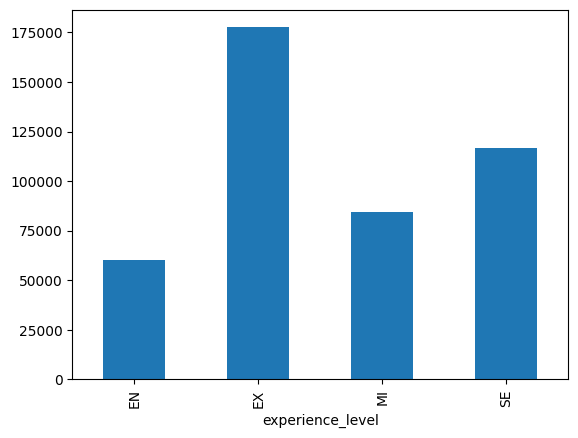

In [25]:
df.groupby('experience_level')['salary_usd'].median().plot(kind='bar')

#Resultados e interpretación

Se observa una progresión salarial consistente a medida que aumenta el nivel de experiencia. El mayor incremento se registra entre los niveles Senior (SE) y Executive (EX), lo que sugiere que los cargos ejecutivos constituyen un segmento claramente diferenciado dentro del mercado laboral.

El crecimiento entre los niveles Entry (EN), Mid (MI) y Senior (SE) es progresivo y mantiene una tendencia estable, aunque no presenta un comportamiento exponencial.

#Hipótesis derivadas

* El mercado laboral recompensa de manera significativa el acceso a posiciones ejecutivas.

* La progresión salarial entre niveles técnicos y senior presenta una evolución gradual y sostenida.

* Sería relevante analizar si esta progresión se mantiene constante en todos los países o si existen variaciones regionales significativas.


#Análisis salarial por país

En este bloque se analiza si existen diferencias salariales significativas según la ubicación de la empresa, y se evalúa si la progresión observada por nivel de experiencia presenta variaciones regionales.


In [26]:
pais_sueldo=df.groupby('company_location')['salary_usd'].median()
pais_sueldo.sort_values(ascending=False).head(10)

,salary_usd
company_location,
Switzerland,152901.00
Denmark,147504.50
Norway,142386.00
United States,128606.00
United Kingdom,115281.00
Singapore,115122.00
Netherlands,112202.00
Sweden,109435.00
Germany,106923.00


In [27]:
df['company_location'].value_counts().sort_values(ascending=False)

,count
company_location,
Germany,814
Denmark,778
Canada,769
France,769
Austria,765
Singapore,764
China,763
India,754
Sweden,752


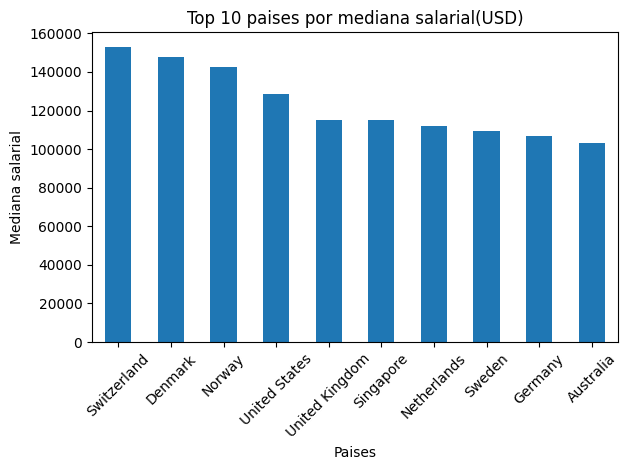

In [28]:
pais_sueldo.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 paises por mediana salarial(USD)")
plt.ylabel("Mediana salarial")
plt.xlabel("Paises")
plt.xticks(rotation=45)
plt.tight_layout()

#Conclusiones

Los países europeos presentan un liderazgo claro. Suiza, Dinamarca y Noruega encabezan el ranking con medianas salariales superiores a 140K USD. Este comportamiento podría estar asociado al costo de vida y a la estructura económica de estos países.

Alemania representa un caso relevante, ya que concentra el mayor volumen de registros; sin embargo, su mediana salarial (106K USD) no la posiciona entre los primeros lugares. Esto evidencia que una mayor cantidad de registros no implica necesariamente niveles salariales más elevados.

En América del Norte, Estados Unidos y Canadá presentan medianas altas, aunque no lideran el ranking global.

No se observa presencia de empresas radicadas en América Latina dentro del ranking analizado. Dado que la distribución de registros es relativamente homogénea entre los países considerados, las diferencias observadas no parecen responder a sesgos significativos de muestra.

#Hipótesis derivadas

*  El nivel salarial podría estar influenciado por el costo de vida y la estructura económica del país.

*  Los mercados nórdicos podrían concentrar una mayor proporción de posiciones senior o ejecutivas.

* La ausencia de empresas latinoamericanas en el ranking requiere un análisis adicional de la variable employee_residence, con el fin de determinar si existe participación de talento latinoamericano empleado por compañías extranjeras.






#América Latina

En este bloque se analiza la participación de países de América Latina dentro del dataset, considerando las variables employee_residence, company_location y remote_ratio.

El objetivo es determinar:


* El nivel de representación de talento latinoamericano.

* Si los profesionales trabajan para empresas radicadas en la región o en el exterior.

* La modalidad de trabajo predominante (presencial, híbrida o remota).





In [29]:
df['employee_residence'].value_counts().sort_values()

,count
employee_residence,
Japan,700
Finland,710
United States,716
Norway,726
Australia,730
Israel,731
Singapore,740
Ireland,740
Switzerland,748


In [30]:
df['employee_residence'].value_counts().sort_values().sum()


np.int64(15000)

#Conclusion

El dataset analizado incluye 15.000 registros distribuidos en 20 países específicos. No se registran empleados ni empresas radicadas en América Latina, lo que indica que la muestra se encuentra geográficamente delimitada a mercados específicos.

En consecuencia, los resultados obtenidos no pueden extrapolarse al mercado laboral latinoamericano..

#Conclusiones generales

A partir del análisis realizado, se observa que los niveles salariales más elevados se concentran en determinados países europeos, especialmente aquellos que lideran el ranking de medianas salariales.

Asimismo, la progresión salarial según nivel de experiencia muestra un crecimiento sostenido entre los niveles Entry, Mid y Senior, sin evidenciar saltos estructurales pronunciados. Sin embargo, se identifica un incremento significativo entre las posiciones Senior y Executive, lo que sugiere una segmentación clara en los niveles más altos del mercado laboral.

Por otro lado, el dataset no incluye países de América Latina, por lo que los resultados se encuentran delimitados a los mercados analizados.

#Limitaciones del dataset

* La muestra se encuentra limitada a 20 países específicos, lo que restringe la posibilidad de generalizar los resultados a nivel global.

* No se dispone de variables que permitan medir el costo de vida o el poder adquisitivo, por lo que las diferencias salariales entre países no pueden analizarse en términos reales.

* La ausencia de países de América Latina impide evaluar la dinámica salarial de dicha región.

#Futuras líneas de análisis


* Analizar un dataset orientado específicamente al mercado salarial y empresarial de América Latina, con el fin de evaluar la dinámica regional.

* Examinar diferencias salariales según modalidad de trabajo (remoto, híbrido o presencial).

* Identificar las posiciones o especializaciones tecnológicas mejor remuneradas.

* Evaluar la interacción entre país, nivel de experiencia y modalidad laboral.

* Incorporar indicadores de costo de vida o paridad de poder adquisitivo (PPP) para analizar los salarios en términos reales y realizar comparaciones internacionales ajustadas.

